<a href="https://colab.research.google.com/github/rocio2403/TPs-ALC-1C2024/blob/Trabajo-Practico-2/grupo_SusanoYValentin_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Trabajo Práctico 2- Contenido Nutricional de la Canasta Básica**

**Grupo** : Susano y Valentín

**Integrantes** :

*   Ibarra, Abril Magalí   LU:
*   Dominguez, Rocio Julieta  LU:798/22


              
           
               

En este trábajo práctico abordamos el estudio del contenido nutricional de la canasta básica de los argentinos.
Para ello, aplicamos los conocimientos adquiridos de reducción de la dimensionalidad, clasificación, espacios vectoriales, mìnimos cuadrados, entre otros.

------
#**Objetivos**
* Analizar la evolución de los precios de los alimentos en la canasta básica.
* Evaluar los cambios en el contenido nutricional de los alimentos.
* Determinar si existe alguna relación entre los precios y el contenido nutricional.
------
Esta notebook se encuentra organizada en secciones, las cuales se corresponden con las consignas dadas


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns


***Preprocesamiento de los datos:***

Cargamos el archivo .csv que contiene la información de la tabla nutricional como un dataframe de Pandas.
Posteriormente, normalizamos para estandarizar los datos.

In [ ]:
def normalizar_tabla_nutricional(tabla_nutricional):
    """
    Dado un dataframe, llena los valores nulos con 0 y convierte los valores en
    miligramos a gramos.
    """
    tabla_nutricional = tabla_nutricional.fillna(0)
    columnas_mg = [col for col in tabla_nutricional.columns if 'mg' in col]
    tabla_nutricional[columnas_mg] /= 1000
    tabla_nutricional.columns = tabla_nutricional.columns.str.replace('mg', 'gr', regex=True)
    return tabla_nutricional

In [ ]:

#Creamos dataframes con los datos en formato csv
tabla_nutricional = pd.read_csv('tabla_nutricional.csv',delimiter= ';')
consumidores_libres = pd.read_csv('consumidores_libres.csv' ,delimiter = ';')

#Normalizamos la tabla
tabla_nutricional = normalizar_tabla_nutricional(tabla_nutricional)

print('Tabla Nutricional', tabla_nutricional.head())

print('Consumidores Libres', consumidores_libres.head())

Tabla Nutricional                 Alimento  Cantidad (gr/ml)  HC (gr)  Proteinas (gr)  \
0    Leche fluida entera            270.00    12.42            8.37   
1  Leche entera en polvo             11.00     4.51            2.84   
2                 Yogurt             19.00     2.45            0.51   
3            Queso crema              1.66     0.06            0.10   
4       Queso cuartirolo              3.66     0.06            0.77   

   Grasas (gr)  Na (gr)  Ca (gr)   Fe (gr)  Azucares Libres (gr)  AGS (gr)  \
0         7.83  0.15390  0.28350  0.000189                   0.0      4.99   
1         2.73  0.04444  0.09900  0.000060                   0.0      1.62   
2         0.49  0.00799  0.01767  0.000005                   0.0      0.32   
3         0.37  0.00123  0.00093  0.000000                   0.0      0.36   
4         0.80  0.02084  0.01654  0.000000                   0.0      0.76   

   AGNI (gr)  AG p (gr)  Fibra (gr)  
0       2.19      0.520         0.0  
1       0.

Posteriormente desarrollamos una función para que dado un dataframe, decida si los valores nutricionales de los elementos de una dieta, se encuentran dentro de los margenes establecidos por la OMS

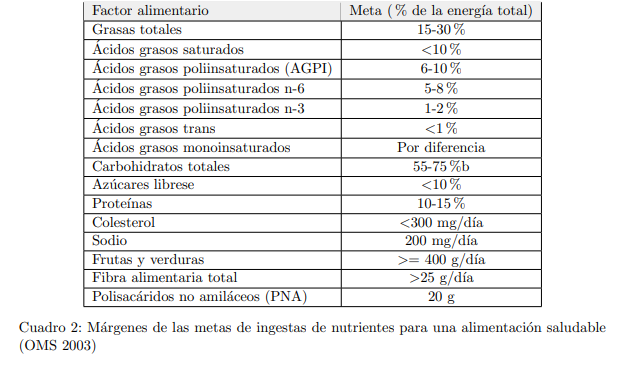

Para realizar las comparaciones, se tuvieron en cuenta las siguientes relaciones:

* Proteínas: 4kcal/g
* Grasas: 9kcal/g
* Carbohidratos: 4kcal/g


In [ ]:

def evaluarCumplimiento_dieta_margenes(data):
    """
    Evalúa si las cantidades de los principales elementos de la dieta, proteínas,
    carbohidratos, grasas, sodio, fibra, frutas y verduras, cumple los márgenes
    de ingesta de la OMS (2750kcal/Dia).

    """
    #Extraemos manualmente las frutas y verduras en la tabla nutricional
    frutas_verduras_lista = ['Acelga', 'Zanahoria', 'Tomate', 'Lechuga', 'Cebolla', 'Zapallo', 'Manzana', 'Naranja', 'Mandarina', 'pera', 'Banana', 'Papa', 'Batata']

    #Calculamos las cantidades totales
    proteinas = data['Proteinas (gr)'].sum()
    carbohidratos = data['HC (gr)'].sum()
    grasas = data['Grasas (gr)'].sum()
    sodio = data['Na (gr)'].sum()
    fibra = data['Fibra (gr)'].sum()
    frutas_verduras = data[data['Alimento'].isin(frutas_verduras_lista)]['Cantidad (gr/ml)'].sum()

    #Comparamos las cantidades totales con los márgenes
    proteinas_cumple = 10 <= ((proteinas*4)/2750)*100 <= 15
    carbohidratos_cumple = 55 <= ((carbohidratos*4)/2750)*100 <=75
    grasas_cumple = 15 <= ((grasas*9)/2750)*100 <= 30
    sodio_cumple = sodio <= 2
    fibra_cumple = fibra > 25
    frutas_verduras_cumple = frutas_verduras >= 400
    print(f'Grasas cumple : {grasas_cumple}')
    print(f'HC cumple : {carbohidratos_cumple}')
    print(f'Proteinas cumple : {proteinas_cumple}')
    print(f'Sodio cumple : {sodio_cumple}')
    print(f'Fibra cumple : {fibra_cumple}')
    print(f'Frutas y verduras cumplen : {frutas_verduras_cumple}')

    cumple = proteinas_cumple and carbohidratos_cumple and grasas_cumple and sodio_cumple and fibra_cumple and frutas_verduras_cumple

    return 'Cumple los márgenes' if cumple else 'No cumple los márgenes'


In [ ]:
#Verificamos si la CBA cumple los márgenes de la OMS
print(evaluarCumplimiento_dieta_margenes(tabla_nutricional))

Grasas cumple : True
HC cumple : True
Proteinas cumple : False
Sodio cumple : False
Fibra cumple : False
Frutas y verduras cumplen : True
No cumple los márgenes


Vemos que tal cual indica la tésis dada, la tabla proporcionada no cumple con los márgenes de ingesta de la OMS.

------



###**Análisis en Componentes Principales**
**¿Qué es la Descomposición en Valores Singulares (SVD)?**

La Descomposición en Valores Singulares es una técnica que descompone una matriz $A$ de tamaño $m \times n$ en tres matrices: una matriz unitaria $U$, una matriz diagonal $\Sigma$ y la matriz unitaria $V^T$:

$A = U \Sigma V^T$

- **$U$**: Es una matriz unitaria de tamaño $m \times m$ cuyas columnas son los vectores singulares izquierdos de $A$.
- **$\Sigma$**: Es una matriz diagonal de tamaño $m \times n$ con los valores singulares de $A$ en la diagonal.
- **$V^T$**: Es la transpuesta de una matriz unitaria $V$ de tamaño $n \times n$ cuyas columnas son los vectores singulares derechos de $A$.

Una de las aplicaciones más comunes de SVD es en el *Análisis de Componentes Principales (PCA)*, donde se utiliza para identificar las direcciones principales en las que varían los datos y para reducir su dimensionalidad.

-----

En nuestro análisis de la canasta básica, utilizamos la SVD para realizar PCA sobre la tabla de valores nutricionales de los alimentos. Esto nos permitirá:

1. **Reducir la Dimensionalidad de los Datos**: Proyectar los datos nutricionales en un subespacio de menor dimensión, conservando la mayor cantidad de información posible,facilitando el análisis de los mismos.
2. **Visualizar los Datos**: Facilitar la visualización y el análisis de las características nutricionales de los alimentos en un espacio bidimensional.
3. **Identificar Patrones y Agrupaciones**: Detectar clusters y patrones en los datos nutricionales, ayudándonos a entender mejor las similitudes y diferencias entre los alimentos.

### Pasos del Análisis

1. **Preparación de los Datos**: Normalización y limpieza de los datos nutricionales.
2. **Cálculo de la SVD**: Descomposición de la matriz de datos nutricionales en sus componentes $U$, $\Sigma$ y $V^T$.
3. **Proyección en el Subespacio**: Uso de los vectores singulares derechos para proyectar los datos en el subespacio generado por los vectores singulares izquierdos.
4. **Visualización y Análisis**: Gráfico de los datos proyectados en el espacio reducido y análisis de los patrones y agrupaciones observadas.
-----

Para ello, realizamos la siguiente función:


In [ ]:
def componentes_principalesSVD(X, k):
    """
    Dada una matriz X, computa su factorización SVD y retorna la proyección
    sobre el subespacio generado por los primeros k vectores singulares izquierdos
    de X y la martriz truncada de la SVD Vt_k.
    """
    # Centramos los vectores columna (características) según sus promedios
    n, d = X.shape
    m=np.mean(X, axis=1)

    X = X - np.tile(m.reshape((len(m), 1)), (1, d))

    # Obtenemos los autovalores y autovectores de la matriz de covarianza
    MCov = np.dot(X.T,X)/X.shape[0]
    avals, avecs = np.linalg.eigh(MCov)
    # Ordenamos los autovalores y autovectores
    indices_ordenados = np.argsort(-avals)
    avals = avals[indices_ordenados]
    avecs = avecs[:, indices_ordenados]
    # Seleccionamos los primeros k vectores singulares derechos de X
    Vt_k = avecs[:, :k]
    # Matriz de reflexión en el eje de la primer componente
    R1 = np.array([[1, 0], [0, -1]])
    # Proyectamos los datos en el subespacio generado por los primeros k vectores singulares izquierdos
    X_proyectado = X @ Vt_k @ R1
    return X_proyectado, Vt_k


In [ ]:
# Reducimos la dimensionalidad de los datos (X) mediante PCA
matriz_nutricional = tabla_nutricional.iloc[:, 1:].values
X_proyectado, Vt_2= componentes_principalesSVD(matriz_nutricional, 2)

In [ ]:
def graficarProyeccion(X_proyectado, alimentos, titulo, n_clusters=4):
    """
    Grafica los alimentos como puntos en el subespacio generado por las 2
    componentes principales, coloreando los puntos según sus clusters.
    """
    # Aplicamos KMeans para encontrar clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(X_proyectado)
    labels = kmeans.labels_

    # Crear DataFrame con el número de cluster y alimento
    df_clusters = pd.DataFrame({
        'Alimento': alimentos,
        'Número de Cluster': labels,

    })

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_proyectado[:, 0], X_proyectado[:, 1], c=labels, cmap='viridis', alpha=0.5)
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.title(titulo)
    plt.colorbar(scatter)
    plt.grid(True)
    plt.show()

    return df_clusters

Además, agrupamos en clusters aquellos datos de valores similares para un posterior análisis.

Veamos el gráfico bidimensional obtenido al reducir la dimensión

C:\Users\Rocio\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Rocio\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


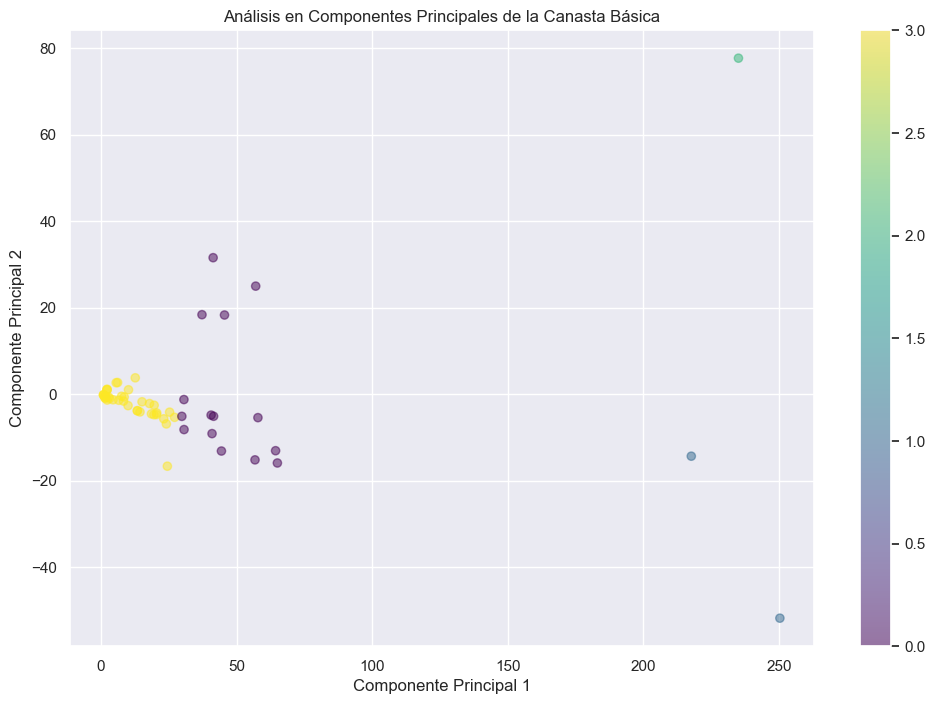

In [ ]:

# Graficamos la proyección con los clusters y obtenemos el DataFrame de clusters
alimentos = tabla_nutricional['Alimento'].values

df_clusters = graficarProyeccion(X_proyectado, alimentos, 'Análisis en Componentes Principales de la Canasta Básica')


Ahora procedamos a analizar los clusters obtenidos:
Teniendo en cuenta que la cantidad de alimentos agrupados en los clusters no es uniforme:

* cantidad de alimentos cluster 1: 15
* cantidad de alimentos cluster 2: 2
* cantidad de alimentos cluster 3: 1
* cantidad de alimentos cluster 4: 39

En el siguiente gráfico, se muestra el promedio de macronutrientes por cluster:

In [ ]:
def graficos_cluster():

    # Para el grupo 1
    grupo1 = df_clusters[df_clusters['Número de Cluster'] == 0]['Alimento'].tolist()
    grupo1 = tabla_nutricional[tabla_nutricional['Alimento'].isin(grupo1)]
    grupo1 = grupo1.merge(df_clusters, on='Alimento', how='left')
    cant1 = len(grupo1)

    # Para el grupo 2
    grupo2 = df_clusters[df_clusters['Número de Cluster'] == 1]['Alimento'].tolist()
    grupo2 = tabla_nutricional[tabla_nutricional['Alimento'].isin(grupo2)]
    grupo2 = grupo2.merge(df_clusters, on='Alimento', how='left')
    cant2 = len(grupo2)

    # Para el grupo 3
    grupo3 = df_clusters[df_clusters['Número de Cluster'] == 2]['Alimento'].tolist()
    grupo3 = tabla_nutricional[tabla_nutricional['Alimento'].isin(grupo3)]
    grupo3 = grupo3.merge(df_clusters, on='Alimento', how='left')
    cant3 = len(grupo3)


    # Para el grupo 4
    grupo4 = df_clusters[df_clusters['Número de Cluster'] == 3]['Alimento'].tolist()
    grupo4 = tabla_nutricional[tabla_nutricional['Alimento'].isin(grupo4)]
    grupo4 = grupo4.merge(df_clusters, on='Alimento', how='left')
    cant4 = len(grupo4)


    # Lista de macronutrientes
    macronutrientes = ['HC (gr)', 'Proteinas (gr)', 'Azucares Libres (gr)', 'Grasas (gr)', 'Fibra (gr)']

    df_combined = pd.concat([grupo1, grupo2, grupo3, grupo4])

    promedios_grupos = df_combined.groupby('Número de Cluster')[macronutrientes].mean().reset_index()
    promedios_grupos['Número de Cluster'] += 1

    sns.set(style="darkgrid")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)

    # Aplanar los ejes para iterar fácilmente
    axes = axes.flatten()


    for idx, macronutriente in enumerate(macronutrientes):
        sns.barplot(ax=axes[idx], x='Número de Cluster', y=macronutriente, data=promedios_grupos, palette='viridis')

        axes[idx].set_title(f'Promedio de {macronutriente} por Cluster')
        axes[idx].set_xlabel('Número de Cluster')
        axes[idx].set_ylabel(macronutriente)

    # Eliminar el último subgráfico si hay menos de 6
    if len(macronutrientes) < len(axes):
        fig.delaxes(axes[-1])

    # Ajustar el layout para evitar solapamientos
    plt.tight_layout()


    plt.show()
    print(f'cantidad de alimentos cluster 1: {cant1}')
    print(f'cantidad de alimentos cluster 2: {cant2}')
    print(f'cantidad de alimentos cluster 3: {cant3}')
    print(f'cantidad de alimentos cluster 4: {cant4}')

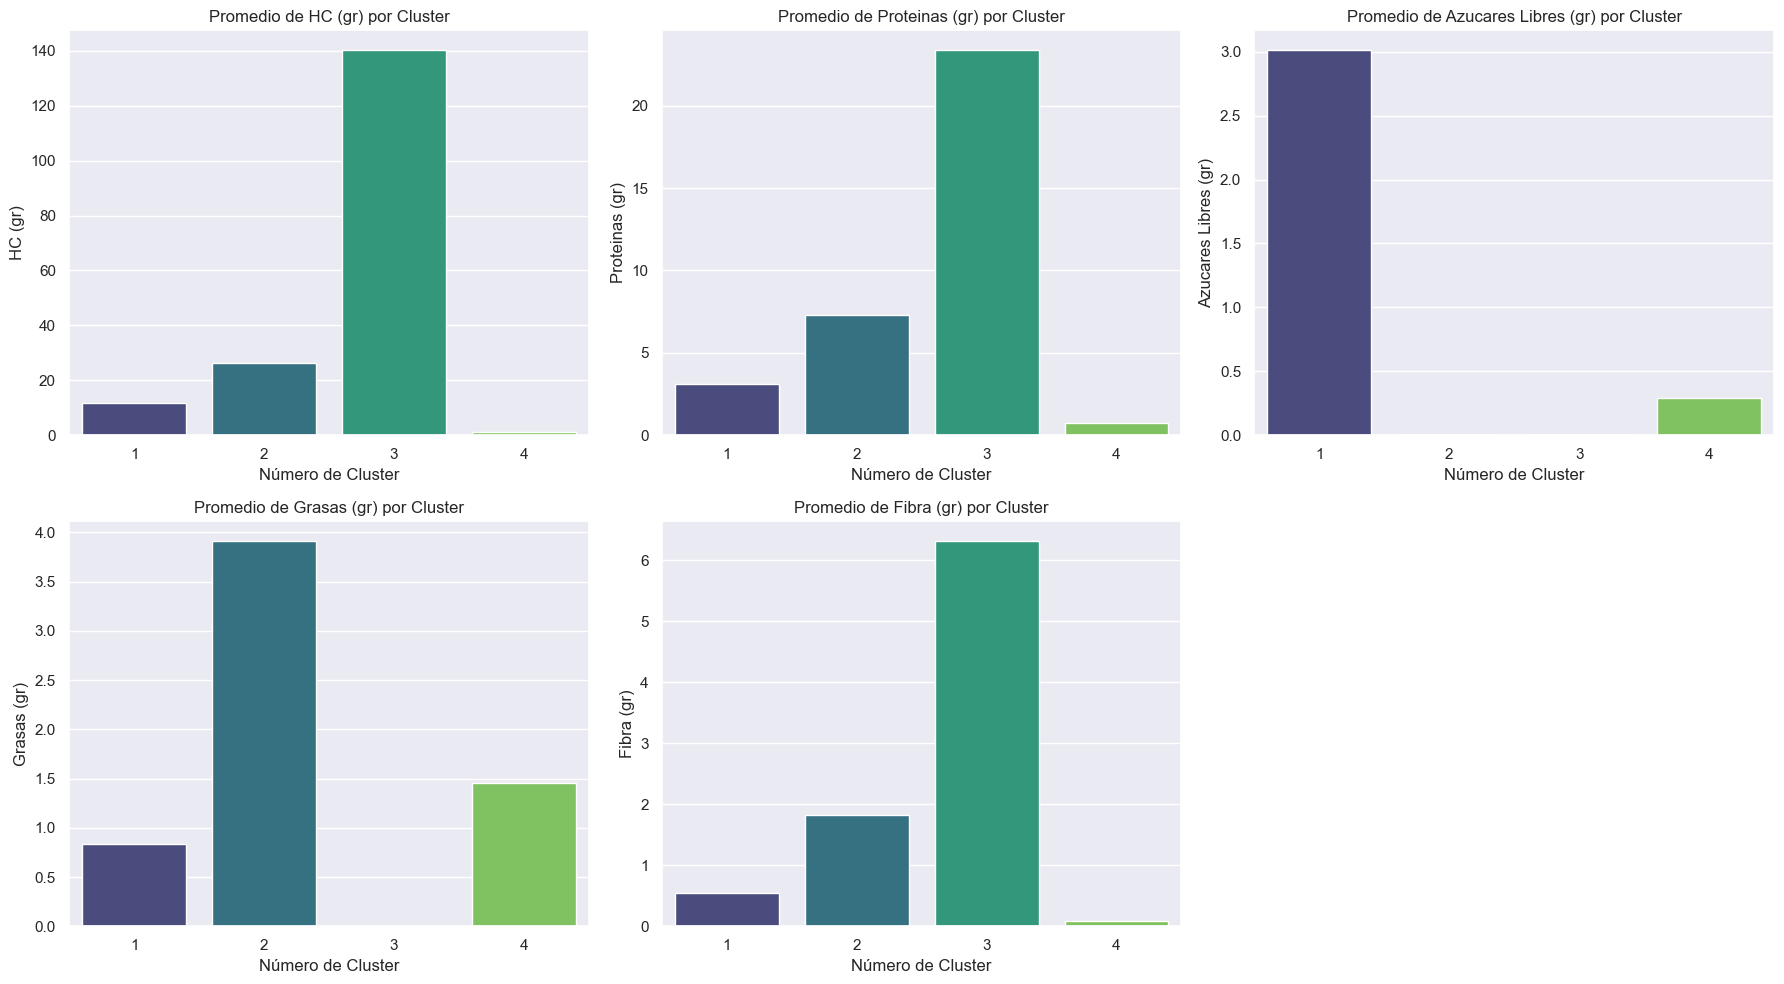

cantidad de alimentos cluster 1: 15
cantidad de alimentos cluster 2: 2
cantidad de alimentos cluster 3: 1
cantidad de alimentos cluster 4: 39


In [ ]:
graficos_cluster()


**Aumentos de Precios**

Proyectamos los alimentos de la tabla de Consumidores Libres en el espacio de generadores del *PCA*.

Para ello, realizamos las siguientes funciones:

In [ ]:
def palabras_contenidas(nombre1, nombre2):
    """
    Verifica si todas las palabras de una cadena (excepto casos excepcionales) están contenidas en otra cadena
    o viceversa, retorna true si se cumple cualquiera de las dos condiciones,
    de lo contrario, retorna false.

    """
    casos_excepcionales =['dulce de leche', 'harina maiz', 'leche entera en polvo', 'paleta cocida', 'tomate envasado', 'vina re']
    if nombre1 not in casos_excepcionales:
        palabras1 = nombre1.split()
        for palabra in palabras1:
            if palabra != 'en' and palabra != 'de' and palabra in nombre2:
                return True
    return

def filtrarAlimentos(Y, X):
    """
    Recibe 2 dataframes de información de alimentos, compara sus primeras columnas
    y devuelve los datos de X filtrados según sus alimentos que aparecen en Y.
    """
    # Convertimos los nombres a minúsculas para una comparación insensible a mayúsculas/minúsculas
    X.iloc[:,0] = X.iloc[:,0].str.lower()
    Y.iloc[:,0] = Y.iloc[:,0].str.lower()

    # Guardamos los alimentos a filtrar
    alimentos_Y = Y.iloc[:,0].tolist()

    #Filtramos
    filtro = X.iloc[:, 0].apply(lambda x: any(palabras_contenidas(x, alimento) for alimento in alimentos_Y))

    return X[filtro]

def proyectar(Y, proyector):
    """
    Proyecta la matriz Y en el subespacio generado por Vt_k obtenido de la matriz X.
    """
    # Centramos Y
    n, d = Y.shape
    m=np.mean(Y, axis=1)
    Y = Y - np.tile(m.reshape((len(m), 1)), (1, d))
    # Matriz de reflexión en el eje de la primer componente
    R1 = np.array([[1, 0], [0, -1]])
    # Proyectamos en el subespacio de las primeras k componentes principales
    Y_proyectado = Y @ proyector @ R1
    return Y_proyectado

C:\Users\Rocio\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Rocio\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


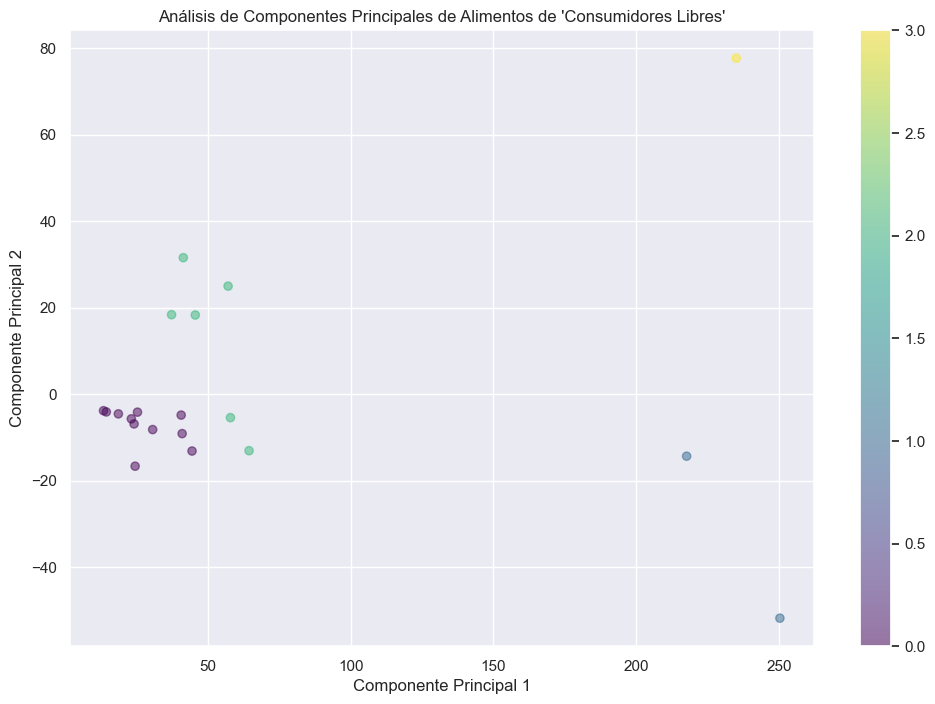

In [ ]:

# Proyectamos los alimentos de consumidores_libres (Y) en el subespacio del PCA anterior
Y = filtrarAlimentos(consumidores_libres, tabla_nutricional)
alimentos2 = Y['Alimento'].values
Y = Y.iloc[:,1:].values
proyector =  Vt_2
Y_proyectado = proyectar(Y, proyector)
# Graficamos la proyección con los clusters y obtenemos el DataFrame de clusters
df_clusters2 = graficarProyeccion(Y_proyectado, alimentos2, "Análisis de Componentes Principales de Alimentos de 'Consumidores Libres'")

***Mínimos cuadrados***

En esta sección, aplicaremos el método de *MínimosCuadrados* para analizar y modelar la relación entre los precios de los alimentos y su contenido nutricional en la canasta básica.

**¿Qué es el Método de Mínimos Cuadrados?**

Es una técnica matemática que se utiliza para ajustar un modelo a los datos observados de manera tal que la suma de los cuadrados de las diferencias (residuos) entre los valores observados y los valores predichos por el modelo sea mínima.

In [ ]:

"""

M´ınimos Cuadrados
Consigna 5.- Aplicar M´ınimos Cuadrados sobre los precios de cada nutriente (HC,
Prote´ınas y grasas) para evaluar el aumento en estos 4 meses. Graficar cada punto
de cada alimento y la recta obtenida por M´ınimos Cuadrados. Hacer una tabla
de los aumentos.

"""
# Convertimos los datos a np.array
matriz_consumidores = consumidores_libres.iloc[:, 1:].values
print(matriz_consumidores.shape)
#no todos los alimentos se corresponden con todos, vamos a filtrar
df= tabla_nutricional[['Alimento', 'Cantidad (gr/ml)', 'HC (gr)', 'Proteinas (gr)', 'Grasas (gr)','Fibra (gr)','Azucares Libres (gr)']]
#ahora vamos a ir filtrando sobre los alimentos que tenemos informacion
#consumidores_libres.rename(columns={"PRODUCTOS": "Alimento"}, inplace=True)
#productos =consumidores_libres.iloc[:, 0] = consumidores_libres.iloc[:, 0].str.lower().str.capitalize()

#tengo que aplicar sobre los precios de cada nutriente pero no tengo de todos, por eso filtro productos
palabras= ['Aceite', 'Acelga','Arroz','Azucar','Carne picada','Fideos secos',
                  'Harina trigo','Huevo','Leche fluida entera','Papa','Tomate','Asado','Cebolla',
                  'Manzana','Naranja']
palabras = [p.lower() for p in palabras]


# Convertir todo a minúsculas para hacer la comparación insensible a mayúsculas y minúsculas
df['Alimento'] = df['Alimento'].astype(str).str.lower()
palabras = [p.lower() for p in palabras]
consumidores_libres['PRODUCTOS'] = consumidores_libres['PRODUCTOS'].astype(str)

# Filtrar filas de df donde alguna columna está incluida o es igual a alguna palabra en palabras
filtrado_df = df[df.apply(lambda row: row.astype(str).str.lower().isin(palabras)).any(axis=1)]




data = []
for index, row in filtrado_df.iterrows():
    aux = consumidores_libres[consumidores_libres['PRODUCTOS'].str.contains(row['Alimento'], case=False, na=False)]

    if len(aux) > 0:
        data.append([row['Alimento'],
                     aux['PRODUCTOS'].iloc[0],
                     aux['Cantidad'].iloc[0],
                     aux['31/12/2023'].iloc[0],
                     aux['31/1/2024'].iloc[0],
                     aux['29/2/2024'].iloc[0],
                     aux['31/3/2024'].iloc[0],
                     aux['30/4/2024'].iloc[0]])

# Crear un nuevo DataFrame con los datos recopilados
df_resultado = pd.DataFrame(data, columns=['Alimento', 'Producto', 'Cantidad', '31/12/2023', '31/1/2024', '29/2/2024', '31/3/2024', '30/4/2024'])
df_final = pd.merge(df_resultado, filtrado_df, on='Alimento', how='inner')
# Mostrar el DataFrame resultante
#AL FIN DIOS
#ASI SE FESTEJA EN EL OBESLISCOOOOOOOOOOOO

#MEJORAR CODIGO LUEGO

#AHORA AGREGO LO QUE ME FALTA
#aceite, leche


#ahora aplico minimos cuadrados para predecir el aumento
#quiero aplicarlo sobre el precio de cada nutriente
#como tengo distintos precios para cada alimento y quiero para los nutrientes, saco la media
#elimino las columnas alimento y prodcuto